# **Model 6 Parameters:**
## **Inputs:** SMILES strings of chemical structures and experimental DMSO-normalized ZBTB11 and IKZF1 abundance values at 10 test MGD concentrations (%)
## **Outputs:** Predicted ZBTB11 and IKZF1 abundance values at each MGD concentration (%)
## **Approach:** Multi-target Chemprop v2 with Optuna wrapper for hyperparameter tuning and Hybrid MSE Curve Fitting + Contrastive Learning Loss Function
### Split single FFN into two separate ZBTB11- and IKZF1-specialized FFNs
## **Baseline:** Ridge Regression on Morgan fingerprints
### Data splitting by computed Bemis-Murcko scaffolds using astartes package
* 80/10/10% train/validation/test

**Package installs and file loading**

In [1]:
# from google.colab import drive
# import os

# drive.mount('/content/drive')
# %cd "/content/drive/MyDrive/Colab Notebooks/ZBTB11 Degraders/model3"

In [2]:
!pip install optuna lightning chemprop ipywidgets umap-learn matplotlib seaborn

In [3]:
!pip install torch --index-url https://download.pytorch.org/whl/cu130

Looking in indexes: https://download.pytorch.org/whl/cu130


In [4]:
!pip install pytorch-metric-learning

In [5]:
# General Use
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Standard Machine Learning & Viz
import umap
import optuna
from sklearn.linear_model import Ridge, RidgeCV
from sklearn.model_selection import validation_curve
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
from scipy.stats import pearsonr

# Cheminformatics
from rdkit import Chem
from rdkit.Chem import AllChem

# Deep Learning Frameworks
import gc
import torch
import torch.nn as torch_nn
import torch.nn.functional as F
from torch.utils.data import DataLoader
from lightning import pytorch as pl
from lightning.pytorch.loggers import CSVLogger
from lightning.pytorch.callbacks import EarlyStopping

# Chemprop (V2)
from chemprop import data, featurizers, models, nn
from chemprop.models import MPNN

# Custom Loss
from pytorch_metric_learning.losses import NTXentLoss

**Synthetic Data Generation**

Uncomment code chunk below if you want to test code adjustments with randomly generated dataset

In [6]:
# print("Generating synthetic molecular glue dataset...")

# # 1. Generate 100 valid SMILES strings
# # We use a basic amide-phenyl scaffold and grow an aliphatic chain to create unique molecules
# smiles_list = [f"O=C(Nc1ccccc1)C{'C'*i}" for i in range(1, 41)] + \
#               [f"O=C(Nc1ccc(Cl)cc1)C{'C'*i}" for i in range(1, 31)] + \
#               [f"O=C(Nc1ccc(F)cc1)C{'C'*i}" for i in range(1, 31)]

# df = pd.DataFrame({'SMILES': smiles_list})

# # 2. Assign distinct splits (70 Train / 15 Val / 15 Test)
# df['Dataset'] = ['Train'] * 70 + ['Val'] * 15 + ['Test'] * 15

# # 3. Generate dummy ZBTB11 data
# # pDC50 between 5.0 (10 uM) and 9.0 (1 nM), Dmax between 20% and 100%
# np.random.seed(42) # For reproducible random numbers
# df['ZBTB11_pDC50'] = np.random.uniform(5.0, 9.0, 100)
# df['ZBTB11_Dmax'] = np.random.uniform(20.0, 100.0, 100)

# # 4. Generate dummy IKZF1 data
# df['IKZF1_pDC50'] = np.random.uniform(4.0, 8.0, 100)
# df['IKZF1_Dmax'] = np.random.uniform(0.0, 100.0, 100)

# # 5. Inject 'NaN' values to simulate Inactive Compounds
# # Let's pick 10 random molecules and make them completely inactive against IKZF1
# inactive_indices = np.random.choice(100, 10, replace=False)
# df.loc[inactive_indices, 'IKZF1_Dmax'] = 0.0
# df.loc[inactive_indices, 'IKZF1_pDC50'] = np.nan # This tests Chemprop's masking feature!

# # 6. Save to CSV
# csv_filename = "zbtb11_mgd_input.csv"
# df.to_csv(csv_filename, index=False)

# print(f"Successfully saved 100 test molecules to '{csv_filename}'.")
# print("\nSample of the generated data:")
# print(df.head())

**Data Splitting and Loading**

In [9]:
import pandas as pd
import numpy as np
from rdkit import Chem
from rdkit.Chem import AllChem
from sklearn.preprocessing import StandardScaler, RobustScaler
from chemprop import data, featurizers
from torch.utils.data import DataLoader

def assign_supcon_classes(df, z_auc_col, i_auc_col, active_max_auc, selectivity_margin):
    z_auc = df[z_auc_col]
    i_auc = df[i_auc_col]
    
    cond_inactive = (z_auc > active_max_auc) & (i_auc > active_max_auc)
    cond_z_selective = (z_auc <= active_max_auc) & ((i_auc > active_max_auc) | ((i_auc - z_auc) >= selectivity_margin))
    cond_i_selective = (i_auc <= active_max_auc) & ((z_auc > active_max_auc) | ((z_auc - i_auc) >= selectivity_margin))
    cond_dual = (z_auc <= active_max_auc) & (i_auc <= active_max_auc) & (abs(z_auc - i_auc) < selectivity_margin)
    
    choices = [0, 1, 2, 3]
    df['SupCon_Class'] = np.select([cond_inactive, cond_z_selective, cond_i_selective, cond_dual], choices, default=0)
    
    print("\n--- SupCon Class Distribution ---")
    print(df['SupCon_Class'].value_counts().sort_index())
    return df

def smiles_to_morgan(smiles_list, radius=2, n_bits=2048):
    fps = []
    for smi in smiles_list:
        mol = Chem.MolFromSmiles(smi)
        if mol is not None:
            fps.append(np.array(AllChem.GetMorganFingerprintAsBitVect(mol, radius, nBits=n_bits)))
        else:
            fps.append(np.zeros((n_bits,)))
    return np.array(fps)


# 1. LOAD FULL DATASET & MERGE 3D FEATURES
df = pd.read_csv("zbtb11_mgd_input.csv")

rf3_df = pd.read_csv("rf3_features_with_thermodynamics.csv")
rf3_subset = rf3_df[['SMILES', 'OpenMM_Minimized_Energy_kJ_mol', 'RF3_ipTM', 'Degron_Interface_Ratio']]

df = df.merge(rf3_subset, on='SMILES', how='inner')

robust_scaler = RobustScaler()
df['Scaled_Energy'] = robust_scaler.fit_transform(df[['OpenMM_Minimized_Energy_kJ_mol']])

extra_feature_cols = ['Scaled_Energy', 'RF3_ipTM', 'Degron_Interface_Ratio']
df[extra_feature_cols] = df[extra_feature_cols].fillna(0)

concs = ['3nM', '10nM', '30nM', '100nM', '300nM', '1uM', '3uM', '10uM', '30uM', '100uM']
targets = [f'zbtb11_{c}' for c in concs] + [f'ikzf1_{c}' for c in concs]

def clean_assay_data(df, target_cols):
    df[target_cols] = df[target_cols].apply(pd.to_numeric, errors='coerce')
    df[target_cols] = df[target_cols].clip(lower=0, upper=100)              
    return df.dropna(subset=target_cols, how='all')                         

df = clean_assay_data(df, targets)

conc_nM = [3, 10, 30, 100, 300, 1000, 3000, 10000, 30000, 100000]
log_conc = np.log10(conc_nM)

zbtb11_cols = [f'zbtb11_{c}' for c in concs]
ikzf1_cols = [f'ikzf1_{c}' for c in concs]

df['True_ZBTB11_AUC'] = df[zbtb11_cols].apply(lambda row: np.trapezoid(y=row.values, x=log_conc), axis=1)
df['True_IKZF1_AUC'] = df[ikzf1_cols].apply(lambda row: np.trapezoid(y=row.values, x=log_conc), axis=1)

df = assign_supcon_classes(df, 'True_ZBTB11_AUC', 'True_IKZF1_AUC', active_max_auc=400.0, selectivity_margin=150.0)
df.to_csv("zbtb11_mgd_auc_labels_input.csv", index=False)

smiles_list = df['SMILES'].tolist()
y_values = df[targets + ['SupCon_Class']].values

x_d_values = df[extra_feature_cols].values


# 2. CREATE CHEM PROP DATAPOINTS & GENERATE SCAFFOLD SPLIT
all_datapoints = [
    data.MoleculeDatapoint.from_smi(smi=smi, y=y, x_d=x) 
    for smi, y, x in zip(smiles_list, y_values, x_d_values)
]

all_mols = [d.mol for d in all_datapoints]
train_idx, val_idx, test_idx = data.make_split_indices(
    all_mols,
    split="scaffold_balanced", 
    sizes=(0.8, 0.1, 0.1), 
    seed=42
)


# 3. APPLY INDICES TO CHEM PROP (DEEP LEARNING PREP)
train_data, val_data, test_data = data.split_data_by_indices(
    all_datapoints, train_idx, val_idx, test_idx
)

featurizer = featurizers.SimpleMoleculeMolGraphFeaturizer()
train_dset = data.MoleculeDataset(train_data[0], featurizer)
val_dset = data.MoleculeDataset(val_data[0], featurizer)
test_dset = data.MoleculeDataset(test_data[0], featurizer)

raw_supcon_labels = [dp.y[-1] for dp in train_data[0]]

output_scaler = train_dset.normalize_targets()

for i, dp in enumerate(train_data[0]):
    dp.y[-1] = raw_supcon_labels[i]

if output_scaler is not None:
    try:
        output_scaler.means[-1] = 0.0
        output_scaler.stds[-1] = 1.0
    except AttributeError:
        output_scaler.mean_[-1] = 0.0
        output_scaler.scale_[-1] = 1.0

val_dset.normalize_targets(output_scaler)
test_dset.normalize_targets(output_scaler)

train_loader = DataLoader(
    train_dset,             
    batch_size=32,         
    shuffle=True,           
    collate_fn=data.collate_batch, 
    drop_last=True          
)

val_loader = DataLoader(
    val_dset,               
    batch_size=32,         
    shuffle=False,          
    collate_fn=data.collate_batch,   
    drop_last=False         
)

test_loader = DataLoader(
    test_dset,              
    batch_size=32,
    shuffle=False,
    collate_fn=data.collate_batch,  
    drop_last=False
)


# 4. APPLY INDICES TO PANDAS/SCIKIT-LEARN (CLASSICAL ML PREP)
train_idx_flat = np.array(train_idx).flatten()
test_idx_flat = np.array(test_idx).flatten()

train_df = df.iloc[train_idx_flat].copy()
test_df = df.iloc[test_idx_flat].copy()

X_train_morgan = smiles_to_morgan(train_df['SMILES'].tolist())
X_test_morgan = smiles_to_morgan(test_df['SMILES'].tolist())

X_train_extra = train_df[extra_feature_cols].values
X_test_extra = test_df[extra_feature_cols].values

X_train_combined = np.hstack([X_train_morgan, X_train_extra])
X_test_combined = np.hstack([X_test_morgan, X_test_extra])

scaler_X = StandardScaler()
X_train_scaled = scaler_X.fit_transform(X_train_combined)
X_test_scaled = scaler_X.transform(X_test_combined)

print("Unified data preparation complete with injected 3D features!")

The return type of make_split_indices has changed in v2.1 - see help(make_split_indices)



--- SupCon Class Distribution ---
SupCon_Class
0    20
2    47
3    21
Name: count, dtype: int64
Unified data preparation complete!


C:\Users\18589\AppData\Local\Python\pythoncore-3.14-64\Lib\site-packages\astartes\main.py:325: ImperfectSplittingWarning: Actual train/test split differs from requested size. Requested train size of 0.80, got 0.82. Requested validation size of 0.10, got 0.09. Requested test size of 0.10, got 0.09. 
  warn(
[22:46:12] DEPRECATION WARNING: please use MorganGenerator
[22:46:12] DEPRECATION WARNING: please use MorganGenerator
[22:46:12] DEPRECATION WARNING: please use MorganGenerator
[22:46:12] DEPRECATION WARNING: please use MorganGenerator
[22:46:12] DEPRECATION WARNING: please use MorganGenerator
[22:46:12] DEPRECATION WARNING: please use MorganGenerator
[22:46:12] DEPRECATION WARNING: please use MorganGenerator
[22:46:12] DEPRECATION WARNING: please use MorganGenerator
[22:46:12] DEPRECATION WARNING: please use MorganGenerator
[22:46:12] DEPRECATION WARNING: please use MorganGenerator
[22:46:12] DEPRECATION WARNING: please use MorganGenerator
[22:46:12] DEPRECATION WARNING: please use 

**Baseline Ridge Regression Model Training and Evaluation**


--- Top Predicted Selective Compounds ---
                                               SMILES  \
73  O=C1C2=CC=C(NC(CN(CC3)CCN3C4=CC=C(OC)C=C4)=O)C...   
69  O=C1C2=CC=C(NC(CN(CCCC3=CC=C(OC)C=C3)C4CCCC4)=...   
77  O=C1CCC(N2C(C(C=CC(NC(NC3(CCCC3)C(NCCC4=CC=C(O...   
46  O=C(N1)CCC(N2C(C(NC3=CC(C4(CCC4)NCC5=CC(S(=O)(...   
45  O=C(N1)CCC(N2C(C(NC3=CC(C4(CCC4)NCC5=CC=C(S(=O...   

    Pred_ZBTB11_Selectivity  True_ZBTB11_Selectivity  Pred_ZBTB11_AUC  \
73               -33.934756              -222.320777       433.625188   
69               -58.226386              -288.607287       428.705444   
77              -109.273555              -141.692576       415.451101   
46              -110.097523                 1.011474       411.931851   
45              -117.039719                 2.552514       391.920451   

    True_ZBTB11_AUC  
73       450.723594  
69       436.649134  
77       438.465436  
46       420.347358  
45       404.461537  


C:\Users\18589\AppData\Local\Python\pythoncore-3.14-64\Lib\site-packages\umap\umap_.py:1887: UserWarning: gradient function is not yet implemented for jaccard distance metric; inverse_transform will be unavailable
  warn(
C:\Users\18589\AppData\Local\Python\pythoncore-3.14-64\Lib\site-packages\umap\umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


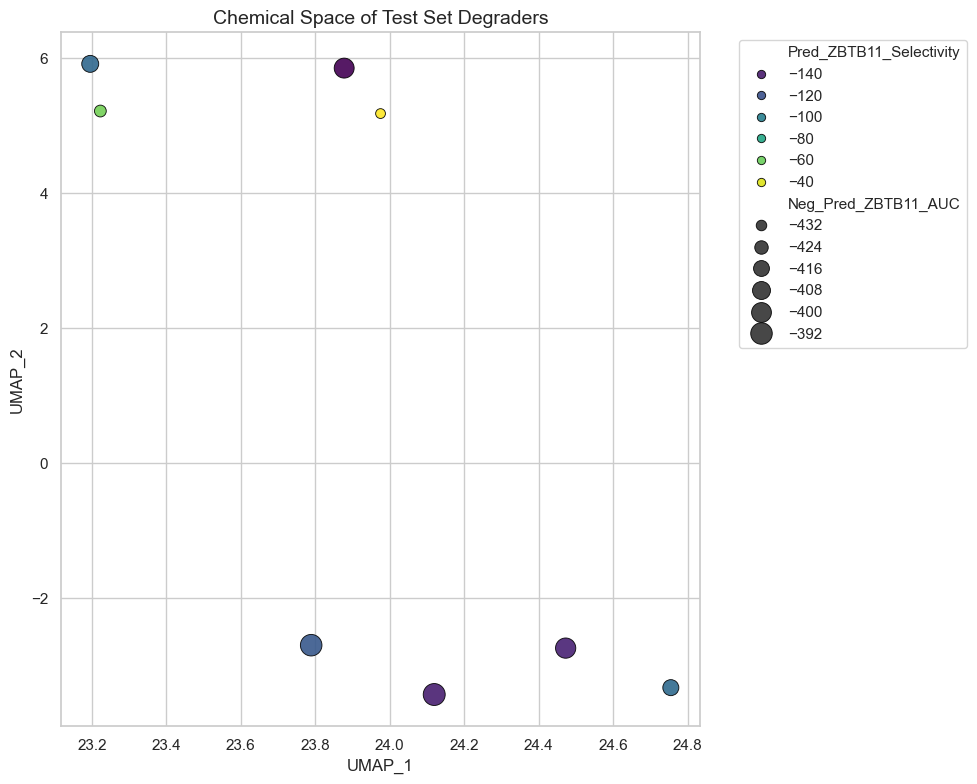


Overall Average Across All Concentrations -> RMSE: 17.942 | R²: -5.830

--- Baseline Regression Metrics (Per Concentration) ---
    Endpoint  N_Valid   RMSE    MAE      R²  Pearson_r
  zbtb11_3nM        8  1.195  1.033   0.137      0.581
 zbtb11_10nM        8  1.970  1.838  -0.815     -0.041
 zbtb11_30nM        8  3.450  3.325 -17.556      0.493
zbtb11_100nM        8  5.238  5.002  -4.078      0.756
zbtb11_300nM        8  7.750  7.639 -31.086      0.722
  zbtb11_1uM        8 10.391  9.919 -47.069     -0.291
  zbtb11_3uM        8  8.890  8.518  -6.557      0.655
 zbtb11_10uM        8  5.860  5.141  -0.744      0.715
 zbtb11_30uM        8  8.838  7.613   0.637      0.855
zbtb11_100uM        8 21.262 17.588   0.402      0.871
   ikzf1_3nM        8  6.711  4.373  -0.162     -0.279
  ikzf1_10nM        8 14.243 11.192  -0.144     -0.345
  ikzf1_30nM        8 27.878 23.366  -0.639     -0.627
 ikzf1_100nM        8 32.992 28.390  -0.800     -0.585
 ikzf1_300nM        8 35.422 31.453  -0.982   

In [10]:
conc_molar = [3e-9, 10e-9, 30e-9, 100e-9, 300e-9, 1e-6, 3e-6, 10e-6, 30e-6, 100e-6]
log_conc = np.log10(conc_molar)


# 1. TRAIN 20 INDEPENDENT RIDGE MODELS
trained_models = {}
alphas = [0.1, 1.0, 10.0, 100.0, 1000.0]

for target in targets:
    y_train = train_df[target].values
    valid_mask = ~np.isnan(y_train)
    
    if valid_mask.sum() > 5:
        model = RidgeCV(alphas=alphas, cv=5)
        model.fit(X_train_scaled[valid_mask], y_train[valid_mask])
        trained_models[target] = model
    else:
        print(f"Warning: Not enough data for {target}. Skipping.")


# 2. PREDICT AND CALCULATE TRUE AREA UNDER CURVE (AUC)

true_target_cols = list(trained_models.keys())
test_results_df = test_df[['SMILES'] + true_target_cols].copy()

for target in trained_models.keys():
    test_results_df[f'Pred_{target}'] = trained_models[target].predict(X_test_scaled)

pred_zbtb11_cols = [f'Pred_zbtb11_{c}' for c in concs if f'zbtb11_{c}' in trained_models]
pred_ikzf1_cols = [f'Pred_ikzf1_{c}' for c in concs if f'ikzf1_{c}' in trained_models]

true_zbtb11_cols = [f'zbtb11_{c}' for c in concs if f'zbtb11_{c}' in trained_models]
true_ikzf1_cols = [f'ikzf1_{c}' for c in concs if f'ikzf1_{c}' in trained_models]

zbtb11_x = [log_conc[i] for i, c in enumerate(concs) if f'zbtb11_{c}' in trained_models]
ikzf1_x = [log_conc[i] for i, c in enumerate(concs) if f'ikzf1_{c}' in trained_models]

test_results_df['Pred_ZBTB11_AUC'] = test_results_df[pred_zbtb11_cols].apply(
    lambda row: np.trapezoid(y=row.values, x=zbtb11_x), axis=1
)
test_results_df['Pred_IKZF1_AUC'] = test_results_df[pred_ikzf1_cols].apply(
    lambda row: np.trapezoid(y=row.values, x=ikzf1_x), axis=1
)

test_results_df['True_ZBTB11_AUC'] = test_results_df[true_zbtb11_cols].apply(
    lambda row: np.trapezoid(y=row.values, x=zbtb11_x), axis=1
)
test_results_df['True_IKZF1_AUC'] = test_results_df[true_ikzf1_cols].apply(
    lambda row: np.trapezoid(y=row.values, x=ikzf1_x), axis=1
)

test_results_df['Pred_ZBTB11_Selectivity'] = test_results_df['Pred_IKZF1_AUC'] - test_results_df['Pred_ZBTB11_AUC']
test_results_df['True_ZBTB11_Selectivity'] = test_results_df['True_IKZF1_AUC'] - test_results_df['True_ZBTB11_AUC']

test_results_df = test_results_df.sort_values(by='Pred_ZBTB11_Selectivity', ascending=False)
test_results_df.to_csv("zbtb11_mgd_ridge_output.csv", index=False)

print("\n--- Top Predicted Selective Compounds ---")
print(test_results_df[['SMILES', 'Pred_ZBTB11_Selectivity', 'True_ZBTB11_Selectivity', 'Pred_ZBTB11_AUC', 'True_ZBTB11_AUC']].head())


# 3. UMAP PLOTTING
test_results_df = test_results_df.sort_index()

reducer = umap.UMAP(n_neighbors=min(5, len(X_test) - 1), min_dist=0.1, metric='jaccard', random_state=42)
embeddings_2d = reducer.fit_transform(X_test)

test_results_df['UMAP_1'] = embeddings_2d[:, 0]
test_results_df['UMAP_2'] = embeddings_2d[:, 1]

test_results_df['Neg_Pred_ZBTB11_AUC'] = -test_results_df['Pred_ZBTB11_AUC']

plt.figure(figsize=(10, 8))
sns.set_theme(style="whitegrid")
scatter = sns.scatterplot(
    data=test_results_df, x='UMAP_1', y='UMAP_2',
    hue='Pred_ZBTB11_Selectivity', palette='viridis',
    size='Neg_Pred_ZBTB11_AUC', sizes=(50, 250), alpha=0.9, edgecolor="black"
)
plt.title("Chemical Space of Test Set Degraders", fontsize=14)
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.savefig("ridge_umap.png", dpi=300, bbox_inches='tight')
plt.show()


# 4. EVALUATE REGRESSION METRICS
evaluation_results = []
valid_targets = list(trained_models.keys())

for true_col in valid_targets:
    pred_col = f'Pred_{true_col}'
    
    y_true = test_df.loc[test_results_df.index, true_col].values
    y_pred = test_results_df[pred_col].values

    valid_mask = ~np.isnan(y_true)
    y_true_valid = y_true[valid_mask]
    y_pred_valid = y_pred[valid_mask]

    if len(y_true_valid) > 1:
        rmse = np.sqrt(mean_squared_error(y_true_valid, y_pred_valid))
        mae = mean_absolute_error(y_true_valid, y_pred_valid)
        r2 = r2_score(y_true_valid, y_pred_valid)
        pearson_r, _ = pearsonr(y_true_valid, y_pred_valid)
    else:
        rmse, mae, r2, pearson_r = np.nan, np.nan, np.nan, np.nan

    evaluation_results.append({
        'Endpoint': true_col,
        'N_Valid': len(y_true_valid),
        'RMSE': round(rmse, 3), 
        'MAE': round(mae, 3),
        'R²': round(r2, 3), 
        'Pearson_r': round(pearson_r, 3)
    })

metrics_df = pd.DataFrame(evaluation_results)
metrics_df.to_csv("zbtb11_mgd_ridge_metrics.csv", index=False)

avg_rmse = metrics_df['RMSE'].mean()
avg_r2 = metrics_df['R²'].mean()
print(f"\nOverall Average Across All Concentrations -> RMSE: {avg_rmse:.3f} | R²: {avg_r2:.3f}")

print("\n--- Baseline Regression Metrics (Per Concentration) ---")
print(metrics_df.to_string(index=False))

**Chemprop Model Training and Evaluation**

C:\Users\18589\AppData\Local\Python\pythoncore-3.14-64\Lib\site-packages\chemprop\nn\transforms.py:13: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.detach().clone() or sourceTensor.detach().clone().requires_grad_(True), rather than torch.tensor(sourceTensor).
  mean = torch.cat([torch.zeros(pad), torch.tensor(mean, dtype=torch.float)])
C:\Users\18589\AppData\Local\Python\pythoncore-3.14-64\Lib\site-packages\chemprop\nn\transforms.py:14: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.detach().clone() or sourceTensor.detach().clone().requires_grad_(True), rather than torch.tensor(sourceTensor).
  scale = torch.cat([torch.ones(pad), torch.tensor(scale, dtype=torch.float)])
[I 2026-03-11 22:49:37,301] A new study created in memory with name: no-name-554d4ea2-c8d1-48c1-90f9-fb7a421c7c2c
C:\Users\18589\AppData\Local\Python\pythoncore-3.14-64\Lib\site-packages\lightning\pytorch\utilities\parsing.py:213: Attribute 'mes

┏━━━┳━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━┳━━━━━━━┳━━━━━━━┓
┃   ┃ Name            ┃ Type               ┃ Params ┃ Mode  ┃ FLOPs ┃
┡━━━╇━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━╇━━━━━━━╇━━━━━━━┩
│ 0 │ message_passing │ BondMessagePassing │  111 K │ train │     0 │
│ 1 │ agg             │ MeanAggregation    │      0 │ train │     0 │
│ 2 │ bn              │ Identity           │      0 │ train │     0 │
│ 3 │ predictor       │ RegressionFFN      │ 40.4 K │ train │     0 │
│ 4 │ X_d_transform   │ Identity           │      0 │ train │     0 │
│ 5 │ metrics         │ ModuleList         │      0 │ train │     0 │
│ 6 │ ntxent_loss     │ NTXentLoss         │      0 │ train │     0 │
│ 7 │ zbtb11_ffn      │ RegressionFFN      │  122 K │ train │     0 │
│ 8 │ ikzf1_ffn       │ RegressionFFN      │  122 K │ train │     0 │
│ 9 │ projection_head │ Sequential         │ 53.1 K │ train │     0 │
└───┴─────────────────┴────────────────────┴────────┴───────┴───────┘

Trainable params: 450 K                                                                                            
Non-trainable params: 0                                                                                            
Total params: 450 K                                                                                                
Total estimated model params size (MB): 1                                                                          
Modules in train mode: 59                                                                                          
Modules in eval mode: 0                                                                                            
Total FLOPs: 0

C:\Users\18589\AppData\Local\Python\pythoncore-3.14-64\Lib\site-packages\lightning\pytorch\utilities\_pytree.py:21: `isinstance(treespec, LeafSpec)` is deprecated, use `isinstance(treespec, TreeSpec) and treespec.is_leaf()` instead.
C:\Users\18589\AppData\Local\Python\pythoncore-3.14-64\Lib\site-packages\lightning\pytorch\trainer\connectors\data_connector.py:434: The 'val_dataloader' does not have many workers which may be a bottleneck. Consider increasing the value of the `num_workers` argument` to `num_workers=31` in the `DataLoader` to improve performance.
C:\Users\18589\AppData\Local\Python\pythoncore-3.14-64\Lib\site-packages\lightning\pytorch\trainer\connectors\data_connector.py:434: The 'train_dataloader' does not have many workers which may be a bottleneck. Consider increasing the value of the `num_workers` argument` to `num_workers=31` in the `DataLoader` to improve performance.
[I 2026-03-11 22:49:38,882] Trial 0 finished with value: 1.1787737607955933 and parameters: {'depth

┏━━━┳━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━┳━━━━━━━┳━━━━━━━┓
┃   ┃ Name            ┃ Type               ┃ Params ┃ Mode  ┃ FLOPs ┃
┡━━━╇━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━╇━━━━━━━╇━━━━━━━┩
│ 0 │ message_passing │ BondMessagePassing │  111 K │ train │     0 │
│ 1 │ agg             │ MeanAggregation    │      0 │ train │     0 │
│ 2 │ bn              │ Identity           │      0 │ train │     0 │
│ 3 │ predictor       │ RegressionFFN      │ 40.4 K │ train │     0 │
│ 4 │ X_d_transform   │ Identity           │      0 │ train │     0 │
│ 5 │ metrics         │ ModuleList         │      0 │ train │     0 │
│ 6 │ ntxent_loss     │ NTXentLoss         │      0 │ train │     0 │
│ 7 │ zbtb11_ffn      │ RegressionFFN      │ 82.4 K │ train │     0 │
│ 8 │ ikzf1_ffn       │ RegressionFFN      │ 82.4 K │ train │     0 │
│ 9 │ projection_head │ Sequential         │ 53.1 K │ train │     0 │
└───┴─────────────────┴────────────────────┴────────┴───────┴───────┘

...

┏━━━┳━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━┳━━━━━━━┳━━━━━━━┓
┃   ┃ Name            ┃ Type               ┃ Params ┃ Mode  ┃ FLOPs ┃
┡━━━╇━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━╇━━━━━━━╇━━━━━━━┩
│ 0 │ message_passing │ BondMessagePassing │  111 K │ train │     0 │
│ 1 │ agg             │ MeanAggregation    │      0 │ train │     0 │
│ 2 │ bn              │ Identity           │      0 │ train │     0 │
│ 3 │ predictor       │ RegressionFFN      │ 40.4 K │ train │     0 │
│ 4 │ X_d_transform   │ Identity           │      0 │ train │     0 │
│ 5 │ metrics         │ ModuleList         │      0 │ train │     0 │
│ 6 │ ntxent_loss     │ NTXentLoss         │      0 │ train │     0 │
│ 7 │ zbtb11_ffn      │ RegressionFFN      │  122 K │ train │     0 │
│ 8 │ ikzf1_ffn       │ RegressionFFN      │  122 K │ train │     0 │
│ 9 │ projection_head │ Sequential         │ 53.1 K │ train │     0 │
└───┴─────────────────┴────────────────────┴────────┴───────┴───────┘

Trainable params: 450 K                                                                                            
Non-trainable params: 0                                                                                            
Total params: 450 K                                                                                                
Total estimated model params size (MB): 1                                                                          
Modules in train mode: 59                                                                                          
Modules in eval mode: 0                                                                                            
Total FLOPs: 0

Output()

C:\Users\18589\AppData\Local\Python\pythoncore-3.14-64\Lib\site-packages\lightning\pytorch\loops\fit_loop.py:317: 
The number of training batches (2) is smaller than the logging interval Trainer(log_every_n_steps=50). Set a lower 
value for log_every_n_steps if you want to see logs for the training epoch.

Metric val_loss improved. New best score: 1.189
Metric val_loss improved by 0.009 >= min_delta = 0.0. New best score: 1.180
Metric val_loss improved by 0.014 >= min_delta = 0.0. New best score: 1.166
Metric val_loss improved by 0.005 >= min_delta = 0.0. New best score: 1.162
Metric val_loss improved by 0.055 >= min_delta = 0.0. New best score: 1.107
Metric val_loss improved by 0.029 >= min_delta = 0.0. New best score: 1.078
Metric val_loss improved by 0.000 >= min_delta = 0.0. New best score: 1.078
Metric val_loss improved by 0.026 >= min_delta = 0.0. New best score: 1.052
Metric val_loss improved by 0.016 >= min_delta = 0.0. New best score: 1.036
Metric val_loss improved by 0.006 >= min_delta = 0.0. New best score: 1.029
Metric val_loss improved by 0.026 >= min_delta = 0.0. New best score: 1.004
Metric val_loss improved by 0.022 >= min_delta = 0.0. New best score: 0.982
Metric val_loss improved by 0.015 >= min_delta = 0.0. New best score: 0.967
Metric val_loss improved by 0.006 >= min

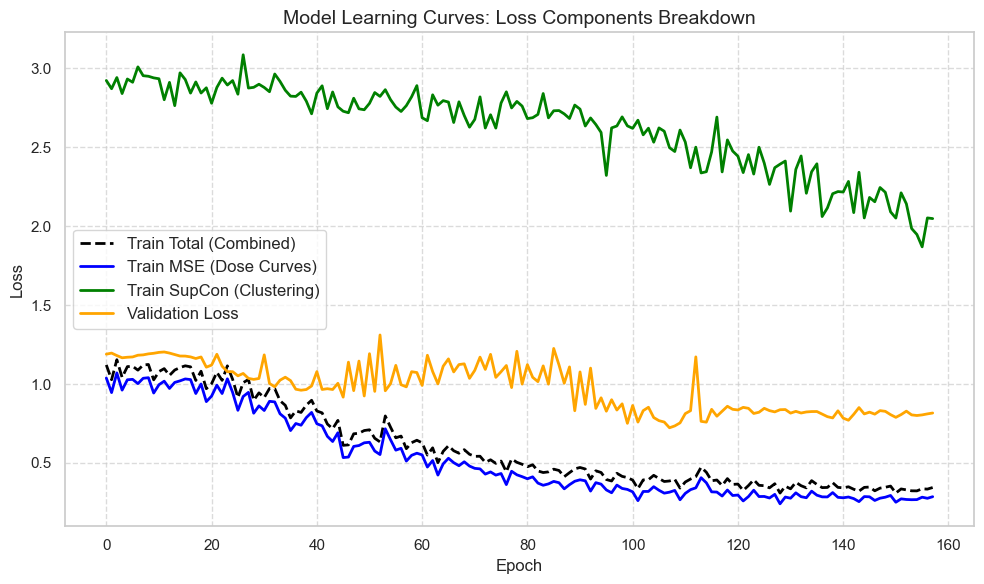

LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]


Output()

C:\Users\18589\AppData\Local\Python\pythoncore-3.14-64\Lib\site-packages\lightning\pytorch\trainer\connectors\data_connector.py:434: The 'predict_dataloader' does not have many workers which may be a bottleneck. Consider increasing the value of the `num_workers` argument` to `num_workers=31` in the `DataLoader` to improve performance.


C:\Users\18589\AppData\Local\Python\pythoncore-3.14-64\Lib\site-packages\umap\umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(



--- Top Predicted Selective Compounds (Ranked by Predicted AUC Differential) ---
                                              SMILES  Pred_ZBTB11_Selectivity  \
7  O=C1C2=CC=C(NC(CN(CC3)CCN3C4=CC=C(OC)C=C4)=O)C...               -26.123681   
3  O=C(N1)CCC(N2C(C(NC3=CC(C4(CCC4)NCC5=CC=C(S(=O...               -36.796537   
4  O=C(N1)CCC(N2C(C(NC3=CC(C4(CCC4)NCC5=CC(S(=O)(...               -45.718683   
6  O=C1C2=CC=C(NC(CN(CCCC3=CC=C(OC)C=C3)C4CCCC4)=...               -72.463999   
0  O=C1CCC(N2C(C(C=CC(NC(NC3(CCCC3)C(NCCC4=CC=C(O...               -75.511976   

   True_ZBTB11_Selectivity  Pred_ZBTB11_AUC  True_ZBTB11_AUC  
7              -222.320777       442.346336       450.723594  
3                 2.552514       426.404189       404.461537  
4                 1.011474       426.149061       420.347358  
6              -288.607287       431.048029       436.649134  
0              -141.692576       430.207280       438.465436  
Extracted fingerprints shape: (8, 200)


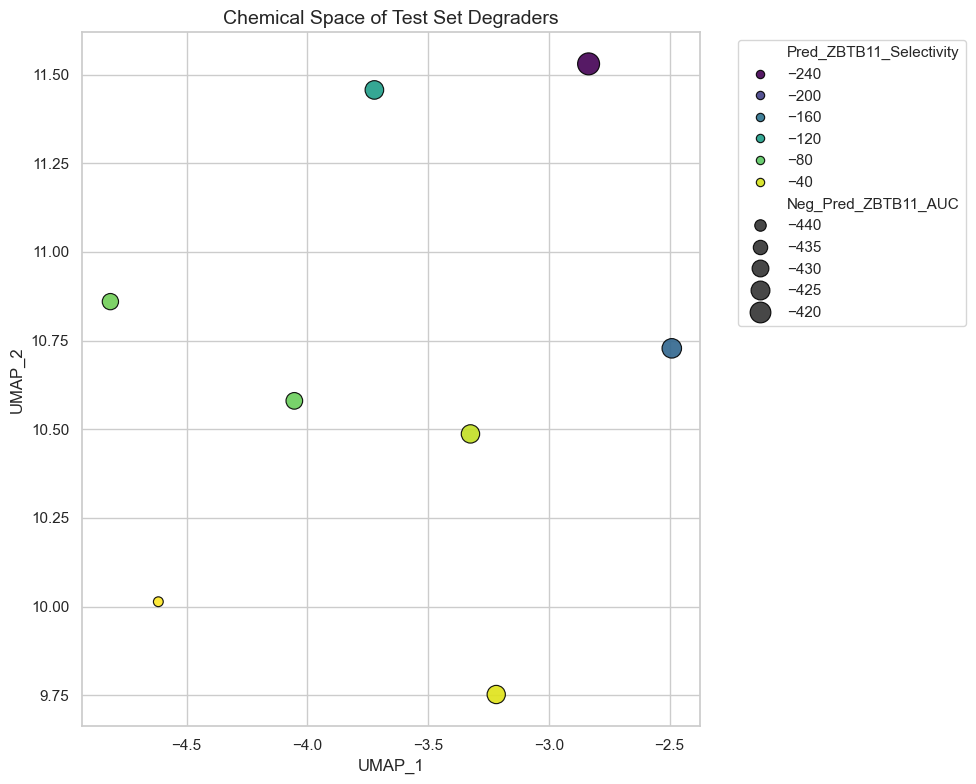


Overall Average Across All Concentrations -> RMSE: 16.645 | R²: -0.624

--- Regression Evaluation Metrics (Per Concentration) ---
    Endpoint  N_Valid_Points   RMSE    MAE     R²  Pearson_r
  zbtb11_3nM               8  1.199  0.899  0.131      0.597
 zbtb11_10nM               8  1.444  1.137  0.025      0.172
 zbtb11_30nM               8  1.048  0.938 -0.712      0.165
zbtb11_100nM               8  2.111  1.667  0.175      0.678
zbtb11_300nM               8  1.720  1.503 -0.581      0.674
  zbtb11_1uM               8  3.051  2.856 -3.144     -0.070
  zbtb11_3uM               8  3.084  2.841  0.091      0.306
 zbtb11_10uM               8  3.984  3.375  0.194      0.534
 zbtb11_30uM               8 14.307 11.346  0.049      0.485
zbtb11_100uM               8 29.418 24.497 -0.145      0.472
   ikzf1_3nM               8  7.757  4.997 -0.552     -0.259
  ikzf1_10nM               8 17.644 11.933 -0.756     -0.299
  ikzf1_30nM               8 29.074 20.745 -0.783     -0.321
 ikzf1_100nM   

In [12]:
# 1. Custom Supervised Contrastive Learning Model Wrapper (Branched Y-Network)
class BranchedSupConMPNN(MPNN):
    def __init__(self, message_passing, agg, d_h, n_layers, dropout, out_transform_z, out_transform_i, supcon_weight, temperature, lr=1e-3, extra_features_dim=0):
        dummy_input_dim = message_passing.output_dim + extra_features_dim
        dummy_ffn = nn.RegressionFFN(n_tasks=1, input_dim=dummy_input_dim, hidden_dim=d_h, n_layers=1)
        super().__init__(message_passing, agg, dummy_ffn)
        
        self.ntxent_loss = NTXentLoss(temperature=temperature)
        self.supcon_weight = supcon_weight
        self.lr = lr 
        
        self.register_buffer("mean_z", out_transform_z.mean.clone().detach().squeeze())
        self.register_buffer("scale_z", out_transform_z.scale.clone().detach().squeeze())
        self.register_buffer("mean_i", out_transform_i.mean.clone().detach().squeeze())
        self.register_buffer("scale_i", out_transform_i.scale.clone().detach().squeeze())
        
        ffn_input_dim = message_passing.output_dim + extra_features_dim
        
        self.zbtb11_ffn = nn.RegressionFFN(
            n_tasks=10,
            input_dim=ffn_input_dim,
            hidden_dim=d_h,
            n_layers=n_layers,
            dropout=dropout
        )
        
        self.ikzf1_ffn = nn.RegressionFFN(
            n_tasks=10,
            input_dim=ffn_input_dim,
            hidden_dim=d_h,
            n_layers=n_layers,
            dropout=dropout
        )
        
        self.projection_head = torch_nn.Sequential(
            torch_nn.Linear(d_h, d_h),
            torch_nn.ReLU(),
            torch_nn.Linear(d_h, 64)
        )

    def _hide_supcon_labels(self, batch): 
        new_Y = batch.Y[:, :20]
        new_w = batch.w[:, :20] if batch.w is not None and batch.w.dim() == 2 and batch.w.shape[1] > 20 else batch.w
        new_lt = batch.lt_mask[:, :20] if batch.lt_mask is not None and batch.lt_mask.dim() == 2 and batch.lt_mask.shape[1] > 20 else batch.lt_mask
        new_gt = batch.gt_mask[:, :20] if batch.gt_mask is not None and batch.gt_mask.dim() == 2 and batch.gt_mask.shape[1] > 20 else batch.gt_mask
        
        return batch._replace(Y=new_Y, w=new_w, lt_mask=new_lt, gt_mask=new_gt)

    def configure_optimizers(self):
        optimizer = torch.optim.Adam(self.parameters(), lr=self.lr, weight_decay=1e-4)
        scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(
            optimizer, 
            T_max=200, 
            eta_min=1e-6
        )
        return {
            "optimizer": optimizer,
            "lr_scheduler": {
                "scheduler": scheduler,
                "interval": "epoch"
            }
        }

    def _get_predictions(self, batch):
        H_v = self.message_passing(batch.bmg, batch.V_d)
        raw_fingerprints = self.agg(H_v, batch.bmg.batch)
        
        if batch.X_d is not None:
            combined_features = torch.cat([raw_fingerprints, batch.X_d], dim=1)
        else:
            combined_features = raw_fingerprints
            
        preds_z = self.zbtb11_ffn(combined_features)
        preds_i = self.ikzf1_ffn(combined_features)
        
        if preds_z.dim() == 3:
            preds_z = preds_z.squeeze(0)
        if preds_i.dim() == 3:
            preds_i = preds_i.squeeze(0)
            
        preds = torch.cat([preds_z, preds_i], dim=1)
        return preds, raw_fingerprints

    def _compute_scaled_loss(self, preds, targets):
        scaled_targets = targets[:, :20]
        
        mask = ~torch.isnan(scaled_targets)
        return F.mse_loss(preds[mask], scaled_targets[mask])

    def training_step(self, batch, batch_idx):
        mod_batch = self._hide_supcon_labels(batch)
        preds, raw_fingerprints = self._get_predictions(mod_batch)
        
        mse_loss = self._compute_scaled_loss(preds, mod_batch.Y)
        
        raw_projections = self.projection_head(raw_fingerprints)
        projected_fps = F.normalize(raw_projections, p=2, dim=1)
        
        supcon_labels = batch.Y[:, 20]
        supcon_loss = self.ntxent_loss(projected_fps, supcon_labels) 
        
        total_loss = mse_loss + (self.supcon_weight * supcon_loss)
        
        self.log("train_mse_loss", mse_loss, on_step=False, on_epoch=True, prog_bar=True)
        self.log("train_supcon_loss", supcon_loss, on_step=False, on_epoch=True, prog_bar=True)
        self.log("train_total_loss", total_loss, on_step=False, on_epoch=True)
        
        return total_loss

    def validation_step(self, batch, batch_idx):
        mod_batch = self._hide_supcon_labels(batch)
        preds, _ = self._get_predictions(mod_batch)
        
        val_loss = self._compute_scaled_loss(preds, mod_batch.Y)
        
        self.log("val_loss", val_loss, on_step=False, on_epoch=True, prog_bar=True)
        return val_loss

    def test_step(self, batch, batch_idx):
        mod_batch = self._hide_supcon_labels(batch)
        preds, _ = self._get_predictions(mod_batch)
        
        test_loss = self._compute_scaled_loss(preds, mod_batch.Y)
        
        self.log("test_loss", test_loss, on_step=False, on_epoch=True, prog_bar=True)
        return test_loss

    def predict_step(self, batch, *args, **kwargs):
        mod_batch = self._hide_supcon_labels(batch)
        preds, _ = self._get_predictions(mod_batch)
        
        preds_z_unscaled = (preds[:, :10] * self.scale_z) + self.mean_z
        preds_i_unscaled = (preds[:, 10:20] * self.scale_i) + self.mean_i
        
        return torch.cat([preds_z_unscaled, preds_i_unscaled], dim=1)


# 2. HYPERPARAMETER TUNING WITH OPTUNA
full_transform = nn.UnscaleTransform.from_standard_scaler(output_scaler)

sliced_mean_zbtb = full_transform.mean[..., :10]
sliced_scale_zbtb = full_transform.scale[..., :10]
out_transform_z = nn.UnscaleTransform(mean=sliced_mean_zbtb, scale=sliced_scale_zbtb)

sliced_mean_ikzf = full_transform.mean[..., 10:20]
sliced_scale_ikzf = full_transform.scale[..., 10:20]
out_transform_i = nn.UnscaleTransform(mean=sliced_mean_ikzf, scale=sliced_scale_ikzf)

def objective(trial):
    depth = trial.suggest_int("depth", 3, 5)
    d_h = trial.suggest_int("d_h", 50, 200, step=50)
    dropout = trial.suggest_float("dropout", 0.1, 0.3, step=0.1)
    n_layers = trial.suggest_int("n_layers", 2, 3)
    lr = trial.suggest_float("lr", 1e-4, 5e-3, log=True)
    supcon_weight = trial.suggest_float("supcon_weight", 0.01, 0.2, log=True)
    temperature = trial.suggest_float("temperature", 0.05, 0.2)

    mp = nn.BondMessagePassing(depth=depth, d_h=d_h)
    agg = nn.MeanAggregation()

    chemprop_model = BranchedSupConMPNN(
        message_passing=mp, 
        agg=agg, 
        d_h=d_h, 
        n_layers=n_layers, 
        dropout=dropout,
        out_transform_z=out_transform_z,
        out_transform_i=out_transform_i,
        supcon_weight=supcon_weight, 
        temperature=temperature,
        lr=lr,
        extra_features_dim=3
    )

    tune_early_stop = EarlyStopping(monitor="val_loss", patience=25, mode="min")

    trainer = pl.Trainer(
        accelerator="auto",
        max_epochs=100,
        enable_checkpointing=False,
        enable_progress_bar=False,
        logger=False,
        callbacks=[tune_early_stop]
    )
    
    trainer.fit(chemprop_model, train_loader, val_loader)
    
    best_score = tune_early_stop.best_score.item()
    
    del chemprop_model
    del trainer
    gc.collect()
    if torch.cuda.is_available():
        torch.cuda.empty_cache()

    return best_score

study = optuna.create_study(direction="minimize")
study.optimize(objective, n_trials=100)
print(f"Best hyperparameters found: {study.best_params}")


# 3. TRAIN FINAL MODEL & PLOT LOSS CURVES
best = study.best_params

final_mp = nn.BondMessagePassing(depth=best["depth"], d_h=best["d_h"])
final_agg = nn.MeanAggregation()

final_model = BranchedSupConMPNN(
    message_passing=final_mp, 
    agg=final_agg, 
    d_h=best["d_h"], 
    n_layers=best["n_layers"], 
    dropout=best["dropout"],
    out_transform_z=out_transform_z,
    out_transform_i=out_transform_i,
    supcon_weight=best["supcon_weight"], 
    temperature=best["temperature"],
    lr=best["lr"],
    extra_features_dim=3
)

logger = CSVLogger("training_logs", name="chemprop_model")

final_early_stop = EarlyStopping(
    monitor="val_loss", 
    min_delta=0.00, 
    patience=50, 
    verbose=True, 
    mode="min"
)

final_trainer = pl.Trainer(
    accelerator="auto",
    min_epochs=100,
    max_epochs=200,
    enable_checkpointing=True,
    enable_progress_bar=True,
    logger=logger,
    callbacks=[final_early_stop]
)

final_trainer.fit(final_model, train_loader, val_loader)

metrics_file = f"{logger.log_dir}/metrics.csv"
metrics_df = pd.read_csv(metrics_file)

val_cols = [c for c in metrics_df.columns if 'val' in c.lower() and 'loss' in c.lower()]
val_col = val_cols[0] if val_cols else None

if val_col and 'train_mse_loss' in metrics_df.columns:
    train_mse = metrics_df[['epoch', 'train_mse_loss']].dropna().groupby('epoch').mean()
    train_supcon = metrics_df[['epoch', 'train_supcon_loss']].dropna().groupby('epoch').mean()
    train_total = metrics_df[['epoch', 'train_total_loss']].dropna().groupby('epoch').mean()
    val_loss = metrics_df[['epoch', val_col]].dropna().groupby('epoch').mean()

    plt.figure(figsize=(10, 6))
    
    plt.plot(train_total.index, train_total['train_total_loss'], label='Train Total (Combined)', color='black', linewidth=2, linestyle='--')
    plt.plot(train_mse.index, train_mse['train_mse_loss'], label='Train MSE (Dose Curves)', color='blue', linewidth=2)
    plt.plot(train_supcon.index, train_supcon['train_supcon_loss'], label='Train SupCon (Clustering)', color='green', linewidth=2)
    plt.plot(val_loss.index, val_loss[val_col], label='Validation Loss', color='orange', linewidth=2)

    plt.title("Model Learning Curves: Loss Components Breakdown", fontsize=14)
    plt.xlabel("Epoch", fontsize=12)
    plt.ylabel("Loss", fontsize=12)
    plt.legend(fontsize=12)
    plt.grid(True, linestyle='--', alpha=0.7)
    plt.tight_layout()
    plt.savefig("learning_curves.png", dpi=300)
    plt.show()
else:
    print("\nError: Could not find the required train or validation loss columns in the logs.")


# 4. DEFINE TARGETS AND X-AXIS FOR INTEGRATION
concs = ['3nM', '10nM', '30nM', '100nM', '300nM', '1uM', '3uM', '10uM', '30uM', '100uM']
conc_molar = [3e-9, 10e-9, 30e-9, 100e-9, 300e-9, 1e-6, 3e-6, 10e-6, 30e-6, 100e-6]
log_conc = np.log10(conc_molar)

true_zbtb11_cols = [f'zbtb11_{c}' for c in concs]
true_ikzf1_cols = [f'ikzf1_{c}' for c in concs]
targets = true_zbtb11_cols + true_ikzf1_cols
pred_cols = [f'Pred_{t}' for t in targets]


# 5. PREDICT & CALCULATE TRUE AUC SELECTIVITY
preds = final_trainer.predict(final_model, test_loader)
preds_tensor = torch.concat(preds, axis=0)

test_smiles = test_df['SMILES'].tolist() 
true_targets = [dp.y[:20] for dp in test_data[0]] 

true_cols = true_zbtb11_cols + true_ikzf1_cols
test_results_df = pd.DataFrame(true_targets, columns=true_cols)
test_results_df.insert(0, 'SMILES', test_smiles)

pred_zbtb11_cols = [f'Pred_{t}' for t in true_zbtb11_cols]
pred_ikzf1_cols = [f'Pred_{t}' for t in true_ikzf1_cols]
test_results_df[pred_zbtb11_cols + pred_ikzf1_cols] = preds_tensor.numpy().reshape(-1, 20)

test_results_df['Pred_ZBTB11_AUC'] = test_results_df[pred_zbtb11_cols].apply(
    lambda row: np.trapezoid(y=row.values, x=log_conc), axis=1
)
test_results_df['Pred_IKZF1_AUC'] = test_results_df[pred_ikzf1_cols].apply(
    lambda row: np.trapezoid(y=row.values, x=log_conc), axis=1
)

test_results_df['True_ZBTB11_AUC'] = test_results_df[true_zbtb11_cols].apply(
    lambda row: np.trapezoid(y=row.values, x=log_conc), axis=1
)
test_results_df['True_IKZF1_AUC'] = test_results_df[true_ikzf1_cols].apply(
    lambda row: np.trapezoid(y=row.values, x=log_conc), axis=1
)

test_results_df['Pred_ZBTB11_Selectivity'] = test_results_df['Pred_IKZF1_AUC'] - test_results_df['Pred_ZBTB11_AUC']
test_results_df['True_ZBTB11_Selectivity'] = test_results_df['True_IKZF1_AUC'] - test_results_df['True_ZBTB11_AUC']

test_results_df = test_results_df.sort_values(by='Pred_ZBTB11_Selectivity', ascending=False)
test_results_df.to_csv("zbtb11_mgd_chemprop_output.csv", index=False)

print("\n--- Top Predicted Selective Compounds (Ranked by Predicted AUC Differential) ---")
print(test_results_df[['SMILES', 'Pred_ZBTB11_Selectivity', 'True_ZBTB11_Selectivity', 'Pred_ZBTB11_AUC', 'True_ZBTB11_AUC']].head())


# 6. EXTRACT LEARNED FINGERPRINTS FROM THE MODEL
final_model.cpu()
final_model.eval()

learned_fingerprints = []

with torch.no_grad():
    for batch in test_loader:
        _, molecule_embeddings = final_model._get_predictions(batch)
        learned_fingerprints.append(molecule_embeddings.cpu().numpy())

embeddings_array = np.vstack(learned_fingerprints)
print(f"Extracted fingerprints shape: {embeddings_array.shape}")


# 7. UMAP DIMENSIONALITY REDUCTION & PLOTTING
import umap
import matplotlib.pyplot as plt
import seaborn as sns

reducer = umap.UMAP(n_neighbors=min(15, len(embeddings_array) - 1), min_dist=0.1, metric='euclidean', random_state=42)
embeddings_2d = reducer.fit_transform(embeddings_array)

test_results_df = test_results_df.sort_index()

test_results_df['UMAP_1'] = embeddings_2d[:, 0]
test_results_df['UMAP_2'] = embeddings_2d[:, 1]

test_results_df['Neg_Pred_ZBTB11_AUC'] = -test_results_df['Pred_ZBTB11_AUC']

plt.figure(figsize=(10, 8))
sns.set_theme(style="whitegrid")
scatter = sns.scatterplot(
    data=test_results_df, x='UMAP_1', y='UMAP_2',
    hue='Pred_ZBTB11_Selectivity', palette='viridis',
    size='Neg_Pred_ZBTB11_AUC', sizes=(50, 250), alpha=0.9, edgecolor="black"
)
plt.title("Chemical Space of Test Set Degraders", fontsize=14)
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.savefig("chemprop_umap.png", dpi=300, bbox_inches='tight')
plt.show()


# 8. EVALUATE REGRESSION METRICS
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
from scipy.stats import pearsonr

y_true_array = np.array([dp.y[:20] for dp in test_data[0]], dtype=float)
y_pred_array = preds_tensor.numpy().reshape(-1, 20)

evaluation_results = []

for idx, (true_col, pred_col) in enumerate(zip(targets, pred_cols)):
    y_true = y_true_array[:, idx]
    y_pred = y_pred_array[:, idx]

    mask = ~np.isnan(y_true)
    y_true_valid = y_true[mask]
    y_pred_valid = y_pred[mask]

    if len(y_true_valid) > 1:
        rmse = np.sqrt(mean_squared_error(y_true_valid, y_pred_valid))
        mae = mean_absolute_error(y_true_valid, y_pred_valid)
        r2 = r2_score(y_true_valid, y_pred_valid)
        pearson_r, _ = pearsonr(y_true_valid, y_pred_valid)
    else:
        rmse, mae, r2, pearson_r = np.nan, np.nan, np.nan, np.nan

    evaluation_results.append({
        'Endpoint': true_col,
        'N_Valid_Points': len(y_true_valid),
        'RMSE': round(rmse, 3),
        'MAE': round(mae, 3),
        'R²': round(r2, 3),
        'Pearson_r': round(pearson_r, 3)
    })

metrics_df = pd.DataFrame(evaluation_results)
metrics_df.to_csv("zbtb11_mgd_chemprop_metrics.csv", index=False)

avg_rmse = metrics_df['RMSE'].mean()
avg_r2 = metrics_df['R²'].mean()
print(f"\nOverall Average Across All Concentrations -> RMSE: {avg_rmse:.3f} | R²: {avg_r2:.3f}")

print("\n--- Regression Evaluation Metrics (Per Concentration) ---")
print(metrics_df.to_string(index=False))

# Conclusions
## Observations: 
* Splitting the single FFN into two specialized FFNs for ZBTB11 and IKZF1 dramatically improves the predictive accuracy on ZBTB11 abundance at biologically relevant concentrations (< 30 uM), while it slightly worsens at 30 and 100 uM. This is likely due to the loss of positive transfer that was present in the single, unified FFN, where shared information about general, non-specific molecular effects e.g. cytotoxicity, solubility, assay interference that was shared between ZBTB11 and IKZF1 datasets was effectively halved by splitting the single FFN.
* On the IKZF1 side, the regression metrics do not improve except at concentrations 3 uM and higher, and they do not improve by much. This indicates that the single FFN model was actually dominated by IKZF1 gradients, as the dedicated IKZF1-specific FFN did not improve on the unified FFN.

## Future Directions:
* I want to incorporate AlphaFold3 modeling and interface scores into this pipeline and observe whether or not this will improve the predictive accuracy of both (or one) models.